In [12]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt


def plot_ndcg_folder(
    folder_path,
    legend_outside=False,
    name_map=None,
    append_filename_to_legend=False,
    title="Embedding / Reranker Comparison",
    svg_save_path=None
):
    if name_map is None:
        name_map = {}

    json_files = [f for f in os.listdir(folder_path) if f.endswith(".json")]

    if len(json_files) == 0:
        raise ValueError("No JSON files found in folder")

    all_series = []

    for json_file in json_files:
        json_path = os.path.join(folder_path, json_file)

        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        raw_model = data.get("embedding_model_key") or data.get("embedding_model", "unknown_model")
        embedding_model = name_map.get(raw_model, raw_model)

        reranking_enabled = data.get("reranking_enabled", False)

        raw_reranker = data.get("reranking_model_key") or data.get("reranking_model", None)
        reranking_model = name_map.get(raw_reranker, raw_reranker) if raw_reranker else None

        avg_results = data["average_results"]

        ks, means, stds = [], [], []

        for key, value in avg_results.items():
            if value is None:
                continue

            k = int(key.replace("ndcg@", ""))

            if isinstance(value, dict):
                mean = value.get("mean")
                std = value.get("std")
            else:
                mean = value
                std = None

            if mean is None:
                continue

            ks.append(k)
            means.append(mean)
            stds.append(std)

        sorted_triples = sorted(zip(ks, means, stds))
        ks    = [x[0] for x in sorted_triples]
        means = [x[1] for x in sorted_triples]
        stds  = [x[2] for x in sorted_triples]

        if reranking_enabled and reranking_model:
            label = f"{embedding_model} + {reranking_model}"
        else:
            label = embedding_model

        if append_filename_to_legend:
            file_base = os.path.splitext(json_file)[0]
            label = f"{label} - {file_base.replace('_', ' ')} distance"

        all_series.append({
            "ks": ks,
            "means": means,
            "stds": stds,
            "label": label,
            "mean_ndcg": float(np.mean(means)),
            "has_std": any(s is not None for s in stds)
        })

    all_series.sort(key=lambda x: x["mean_ndcg"], reverse=True)

    width = 12 if not legend_outside else 22

    fig1, ax1 = plt.subplots(figsize=(width, 8))

    for s in all_series:
        line, = ax1.plot(s["ks"], s["means"], marker="o", label=s["label"])
        s["color"] = line.get_color()

    ax1.set_xlabel("k")
    ax1.set_ylabel("Average NDCG @ k")
    ax1.set_title(title)
    ax1.grid(True)
    ax1.set_xticks(range(min(s["ks"]), max(s["ks"]) + 1, 5))

    handles1, labels1 = ax1.get_legend_handles_labels()
    if legend_outside:
        ax1.legend(handles1, labels1, bbox_to_anchor=(1.02, 1), loc="upper left")
        fig1.tight_layout(rect=[0, 0, 0.8, 1])
    else:
        ax1.legend(handles1, labels1)
        fig1.tight_layout()

    if svg_save_path is not None:
        base, ext = os.path.splitext(svg_save_path)
        fig1.savefig(f"{base}_mean{ext}", format="svg", bbox_inches="tight")

    any_has_std = any(s["has_std"] for s in all_series)

    if any_has_std:
        fig2, ax2 = plt.subplots(figsize=(width, 8))

        for s in all_series:
            if not s["has_std"]:
                continue
            std_vals = [v if v is not None else 0.0 for v in s["stds"]]
            ax2.plot(s["ks"], std_vals, marker="o", color=s["color"], label=s["label"])

        ax2.set_xlabel("k")
        ax2.set_ylabel("Std Dev of NDCG @ k")
        ax2.set_title(f"{title} — Variance")
        ax2.grid(True)
        ax2.set_xticks(range(min(s["ks"]), max(s["ks"]) + 1, 5))

        handles2, labels2 = ax2.get_legend_handles_labels()
        if legend_outside:
            ax2.legend(handles2, labels2, bbox_to_anchor=(1.02, 1), loc="upper left")
            fig2.tight_layout(rect=[0, 0, 0.8, 1])
        else:
            ax2.legend(handles2, labels2)
            fig2.tight_layout()

        if svg_save_path is not None:
            base, ext = os.path.splitext(svg_save_path)
            fig2.savefig(f"{base}_std{ext}", format="svg", bbox_inches="tight")

    plt.show()


NAME_MAP = {
    "BAAI/bge-m3": "BGE-M3",
    "bge-m3": "BGE-M3",
    "EMBEDDIA/sloberta": "SloBERTa",
    "sloberta": "SloBERTa",
    "sentence-transformers/all-mpnet-base-v2": "mpnet",
    "sentence-transformers/all-MiniLM-L6-v2": "miniLM",
    "cross-encoder/ms-marco-MiniLM-L6-v2": "ms-marco-MiniLM",
    "BAAI/bge-reranker-v2-m3": "BGE-reranker",
    "bge": "BGE-reranker",
    "cjvt/crosloengual-bert-si-nli": "CroSloEngual",
    "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1": "mmarco-mMiniLMv2",
    "mmarco": "mmarco-mMiniLMv2"
}

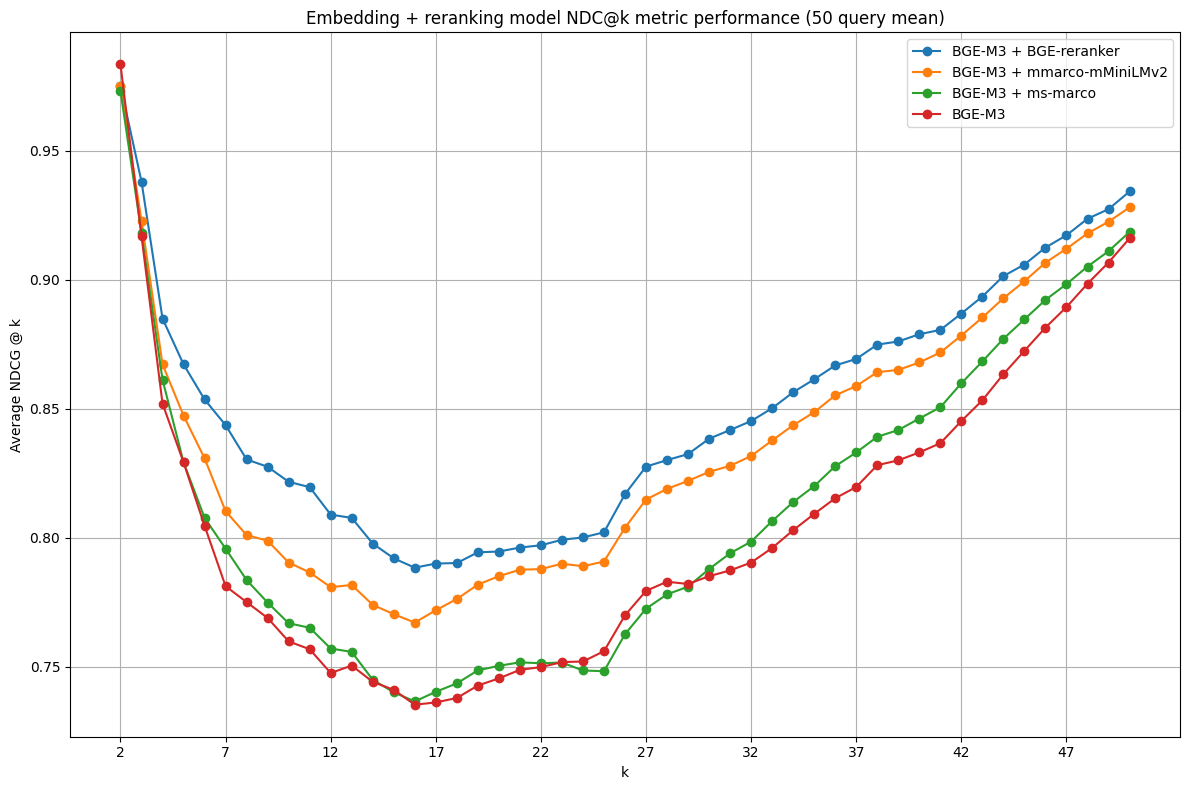

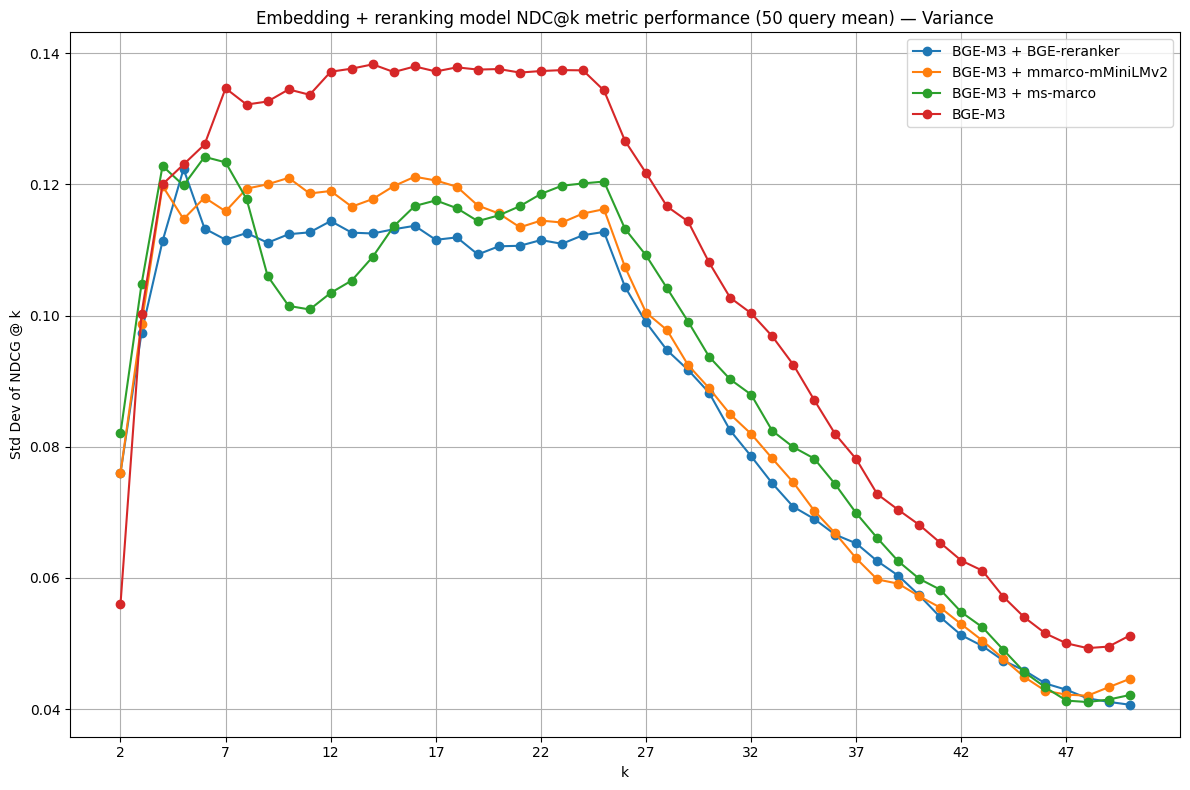

In [13]:

plot_ndcg_folder(
    './',
    title='Embedding + reranking model NDC@k metric performance (50 query mean)', 
    legend_outside=False, 
    name_map=NAME_MAP,
    svg_save_path='./model_reranker_llm_scored.svg'
)